# Solution: Challenge Week 09

## Libraries and settings

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Libraries
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from requests_html import HTMLSession

# Show current working directory
print(os.getcwd())

/workspace/Week_09/challenge


## Define RSS feed URLs

In [2]:
# RSS feed URLs (German and English)
RSS_FEEDS = [
    'https://www.spiegel.de/schlagzeilen/index.rss',
    'https://www.nzz.ch/international.rss',
    'https://rss.nytimes.com/services/xml/rss/nyt/Europe.xml',
    'https://rss.nytimes.com/services/xml/rss/nyt/World.xml',
]

print(f'{len(RSS_FEEDS)} RSS feeds defined.')

4 RSS feeds defined.


## Function to collect a single RSS feed

In [9]:
def collect_rss_feed(url):
    """
    Collect a single RSS feed and return a pandas DataFrame with
    columns: feed_url, title, pub_date, description.

    Parameters
    ----------
    url : str
        URL of the RSS feed.

    Returns
    -------
    pd.DataFrame
        DataFrame with one row per feed item.
    """
    session = HTMLSession()
    response = session.get(url, timeout=15)
    response.raise_for_status()

    items = response.html.find('item')

    records = []
    for item in items:
        title_el   = item.find('title',       first=True)
        date_el    = item.find('pubDate',      first=True)
        desc_el    = item.find('description', first=True)

        records.append({
            'feed_url'   : url,
            'title'      : title_el.text   if title_el   else None,
            'pub_date'   : date_el.text    if date_el    else None,
            'description': desc_el.text    if desc_el    else None,
        })

    return pd.DataFrame(records)


# Test with the first feed
df_single = collect_rss_feed(RSS_FEEDS[0])
print(f'Items collected from first feed: {len(df_single)}')
df_single.head(5)

Items collected from first feed: 30


,feed_url,title,pub_date,description
0,https://www.spiegel.de/schlagzeilen/index.rss,Bafög: Dorothee Bär zeigt sich optimistisch tr...,"Wed, 22 Apr 2026 17:27:00 +0200","Die große Bafög-Reform droht festzustecken, we..."
1,https://www.spiegel.de/schlagzeilen/index.rss,»The Boys«: »Hughie Campbell« und »Victoria Ne...,"Wed, 22 Apr 2026 17:25:00 +0200",Hochzeit im Supes-Universum: Claudia Doumit un...
2,https://www.spiegel.de/schlagzeilen/index.rss,News des Tages: Sollten wir Ramstein in Trumps...,"Wed, 22 Apr 2026 17:08:00 +0200","In der Ukraine diskutieren sie, einen Donbass-..."
3,https://www.spiegel.de/schlagzeilen/index.rss,»Die große Hitze« von Denise Mina: Sie lieben ...,"Wed, 22 Apr 2026 17:08:00 +0200",Viele männliche Autoren sind daran gescheitert...
4,https://www.spiegel.de/schlagzeilen/index.rss,Jonathan Meese: Nachruf auf seine Mutter und E...,"Wed, 22 Apr 2026 17:07:00 +0200",Sein Herz sei zerbrochen: Der Künstler Jonatha...


## Function to collect multiple RSS feeds

In [4]:
def collect_multiple_rss_feeds(urls):
    """
    Collect multiple RSS feeds and return a single combined DataFrame.

    Parameters
    ----------
    urls : list of str
        List of RSS feed URLs.

    Returns
    -------
    pd.DataFrame
        Combined DataFrame with one row per item across all feeds.
    """
    frames = []
    for url in urls:
        try:
            df = collect_rss_feed(url)
            frames.append(df)
            print(f'  OK  ({len(df):>3} items)  {url}')
        except Exception as exc:
            print(f'  FAIL             {url}  ->  {exc}')

    if not frames:
        return pd.DataFrame()

    combined = pd.concat(frames, ignore_index=True)
    return combined


# Collect all feeds
print('Collecting RSS feeds ...')
df_all = collect_multiple_rss_feeds(RSS_FEEDS)

print(f'\nTotal items collected : {len(df_all)}')
print(f'Shape                 : {df_all.shape}')
df_all.head()

  OK  ( 30 items)  https://www.spiegel.de/schlagzeilen/index.rss
  OK  ( 65 items)  https://www.nzz.ch/international.rss
  OK  ( 20 items)  https://rss.nytimes.com/services/xml/rss/nyt/Europe.xml
  OK  ( 59 items)  https://rss.nytimes.com/services/xml/rss/nyt/World.xml

Total items collected : 174
Shape                 : (174, 4)


,feed_url,title,pub_date,description
0,https://www.spiegel.de/schlagzeilen/index.rss,Bafög: Dorothee Bär zeigt sich optimistisch tr...,"Wed, 22 Apr 2026 17:27:00 +0200","Die große Bafög-Reform droht festzustecken, we..."
1,https://www.spiegel.de/schlagzeilen/index.rss,»The Boys«: »Hughie Campbell« und »Victoria Ne...,"Wed, 22 Apr 2026 17:25:00 +0200",Hochzeit im Supes-Universum: Claudia Doumit un...
2,https://www.spiegel.de/schlagzeilen/index.rss,News des Tages: Sollten wir Ramstein in Trumps...,"Wed, 22 Apr 2026 17:08:00 +0200","In der Ukraine diskutieren sie, einen Donbass-..."
3,https://www.spiegel.de/schlagzeilen/index.rss,»Die große Hitze« von Denise Mina: Sie lieben ...,"Wed, 22 Apr 2026 17:08:00 +0200",Viele männliche Autoren sind daran gescheitert...
4,https://www.spiegel.de/schlagzeilen/index.rss,Jonathan Meese: Nachruf auf seine Mutter und E...,"Wed, 22 Apr 2026 17:07:00 +0200",Sein Herz sei zerbrochen: Der Künstler Jonatha...


## Most frequent words per RSS feed title

In [5]:
# Stop words to exclude from frequency counts
STOP_WORDS = {
    # English
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'as', 'by', 'from', 'is', 'are', 'was', 'were', 'be',
    'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will',
    'would', 'could', 'should', 'may', 'might', 'it', 'its', 'that',
    'this', 'these', 'those', 'not', 'no', 'nor', 'so', 'yet', 'both',
    'about', 'after', 'before', 'into', 'over', 'than', 'up', 'out',
    # German
    'der', 'die', 'das', 'ein', 'eine', 'und', 'oder', 'aber', 'in',
    'im', 'am', 'an', 'auf', 'zu', 'von', 'mit', 'ist', 'sind', 'war',
    'für', 'nach', 'bei', 'auch', 'als', 'wie', 'so', 'sich', 'dem',
    'des', 'den', 'um', 'er', 'sie', 'es', 'nicht', 'noch', 'aus',
}


def top_words(df, n=10):
    """
    Find the n most frequent words in the 'title' column of df.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame that contains a 'title' column.
    n  : int
        Number of top words to return.

    Returns
    -------
    list of (word, count) tuples
    """
    all_words = []
    for title in df['title'].dropna():
        words = title.lower().split()
        # Remove punctuation and stop words
        words = [
            w.strip('.,!?;:\'"()[]{}–-')
            for w in words
            if w.strip('.,!?;:\'"()[]{}–-') not in STOP_WORDS
            and len(w.strip('.,!?;:\'"()[]{}–-')) > 1
        ]
        all_words.extend(words)

    return Counter(all_words).most_common(n)


# Print top 10 words per feed
for url in RSS_FEEDS:
    df_feed = df_all[df_all['feed_url'] == url]
    words   = top_words(df_feed, n=10)
    feed_name = url.split('/')[2]          # e.g. 'www.spiegel.de'
    print(f'\n--- {feed_name} ({len(df_feed)} items) ---')
    for word, count in words:
        print(f'  {count:>3}x  {word}')


--- www.spiegel.de (30 items) ---
    2x  trotz
    2x  offenbar
    2x  sollten
    2x  lieben
    2x  kinder
    2x  kabinett
    2x  russland
    1x  bafög
    1x  dorothee
    1x  bär

--- www.nzz.ch (65 items) ---
   12x  trump
    8x  iran
    6x  orban
    5x  ukraine
    5x  waffenruhe
    5x  donald
    5x  vor
    5x  doch
    4x  gibt
    4x  hat

--- rss.nytimes.com (20 items) ---
    4x  ukraine
    3x  iran
    2x  trump
    2x  orban
    2x  europe
    2x  part
    1x  blinked
    1x  first
    1x  extending
    1x  cease-fire

--- rss.nytimes.com (59 items) ---
   10x  iran
   10x  u.s
    7x  trump
    5x  talks
    4x  forces
    4x  cease-fire
    4x  home
    4x  killed
    4x  hormuz
    4x  how


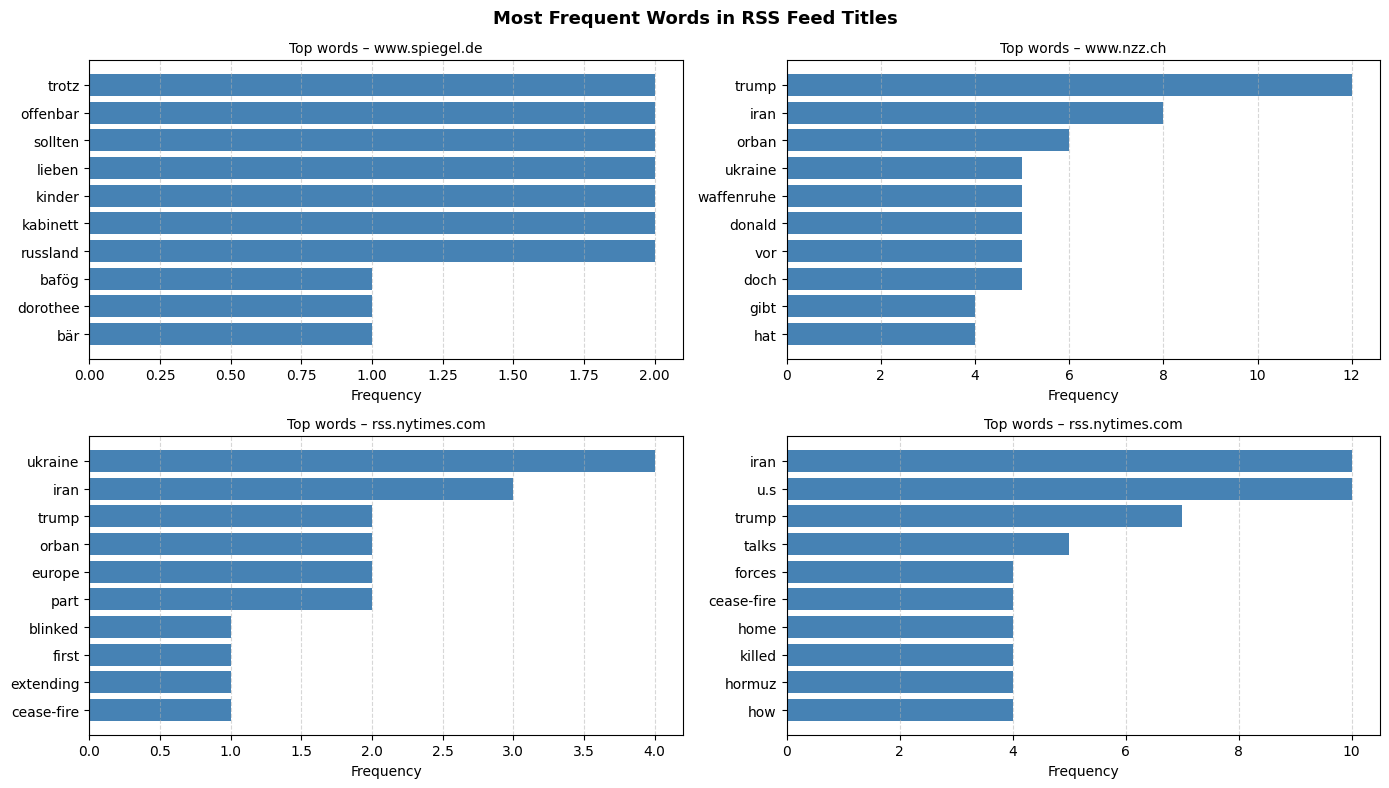

In [6]:
# Bar chart: top 10 words per feed
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, url in zip(axes, RSS_FEEDS):
    df_feed   = df_all[df_all['feed_url'] == url]
    words     = top_words(df_feed, n=10)
    feed_name = url.split('/')[2]

    if words:
        labels, counts = zip(*words)
        ax.barh(labels[::-1], counts[::-1], color='steelblue')
        ax.set_title(f'Top words – {feed_name}', fontsize=10)
        ax.set_xlabel('Frequency')
        ax.grid(axis='x', linestyle='--', alpha=0.5)
    else:
        ax.set_title(f'{feed_name} (no data)')

plt.suptitle('Most Frequent Words in RSS Feed Titles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Word cloud from all RSS feed titles

Total words used for word cloud: 1448


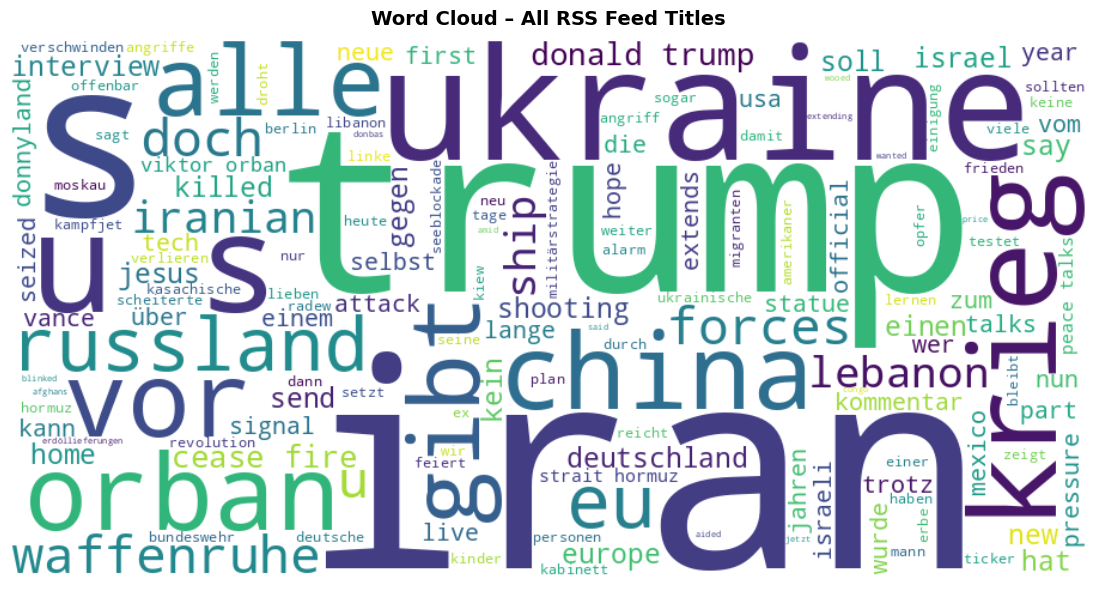

In [7]:
# Combine all titles into a single string (excluding stop words)
all_words_list = []
for title in df_all['title'].dropna():
    words = title.lower().split()
    words = [
        w.strip('.,!?;:\'"()[]{}–-')
        for w in words
        if w.strip('.,!?;:\'"()[]{}–-') not in STOP_WORDS
        and len(w.strip('.,!?;:\'"()[]{}–-')) > 1
    ]
    all_words_list.extend(words)

text_for_cloud = ' '.join(all_words_list)
print(f'Total words used for word cloud: {len(all_words_list)}')

# Generate word cloud
wc = WordCloud(
    width=900,
    height=450,
    background_color='white',
    max_words=150,
    colormap='viridis',
).generate(text_for_cloud)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud – All RSS Feed Titles', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [8]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1044-azure
Datetime: 2026-04-22 15:40:16
Python Version: 3.11.14
-----------------------------------
